# A. Bibliotecas

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

# B. Dataset e variáveis 

In [3]:
df_baseED = pd.read_excel('https://github.com/JuPLopez/JL_mba_enap/raw/refs/heads/main/Estatistica_Descritiva/df_baseED.xlsx')
df_baseED.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314 entries, 0 to 313
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              314 non-null    int64  
 1   cnuc                    314 non-null    object 
 2   unidade de conservação  314 non-null    object 
 3   área_ha_uc              314 non-null    float64
 4   2008                    314 non-null    float64
 5   2009                    131 non-null    float64
 6   2010                    314 non-null    float64
 7   2011                    269 non-null    float64
 8   2012                    176 non-null    float64
 9   2013                    314 non-null    float64
 10  2014                    314 non-null    float64
 11  2015                    176 non-null    float64
 12  2016                    314 non-null    float64
 13  2017                    314 non-null    float64
 14  2018                    314 non-null    fl

### Tipo de cada variável
Os campos (0) cnuc, (1) unidade de conservação e (19) Nome da UC são identificadores da Unidade de Conservação (UC).
<br>O campo (2) área_ha_uc é uma variável quantivativa contínua que indica a área, em hectares, da UC.
<br>Os campos de (3) 2008 a (18) 2023 são variáveis quantivativas contínuas que indicam a área desmatada anualmente, em hectares, da UC no respectivo ano.
<br>O campo (20) UF é uma variável qualitativa nominal que indica a(s) unidadade(s) federativa(s) em que a UC se localiza
<br>O campo (21) Plano de Manejo é uma variável qualitativa nominal que indica se a UC tem Plano de Manejo publicado
<br>O campo(22) Categoria (Sigla) é uma variável qualitativa nominal que indica a categoria de conservação da UC conforme o Sistema Nacional de UCs (SNUC) 
<br>O campo (23) Grupo (Sigla) é uma variável qualitativa nominal que indica o grupo de conservação da UC conforme o Sistema Nacional de UCs (SNUC) (Uso Sustentável ou Proteção Integral)
<br>O campo (24) Bioma é uma variável qualitativa nominal que indica o bioma predominante na UC
<br>O campo (25) Ano de Criação é variável quantitativa discreta que indica o ano de criação da UC

### Frequência de cada variável

#### Variável: Área da Unidade de Conservação
As Unidades de Conservação tem área bastante variável, algumas (cerca de 20) com menos de 1.000 ha e outras (cerca de 15) com mais de 1.000.000ha. A menor UC tem 89ha e a maior 3.865.168ha. VER DESCRIBE E FALAR SOBRE DESBALANCEAMENTO DE TODAS AS AMOSTRAS

In [4]:
# (2) área_ha_uc: variável quantivativa contínua
df_baseED['área_ha_uc'].describe()

count    3.140000e+02
mean     2.680489e+05
std      4.779232e+05
min      0.000000e+00
25%      1.136600e+04
50%      7.559946e+04
75%      3.060708e+05
max      3.865169e+06
Name: área_ha_uc, dtype: float64

area
1000-9999         48
10000-99999       94
100000-999999    132
<1000             25
>=1000000         15
Name: count, dtype: int64


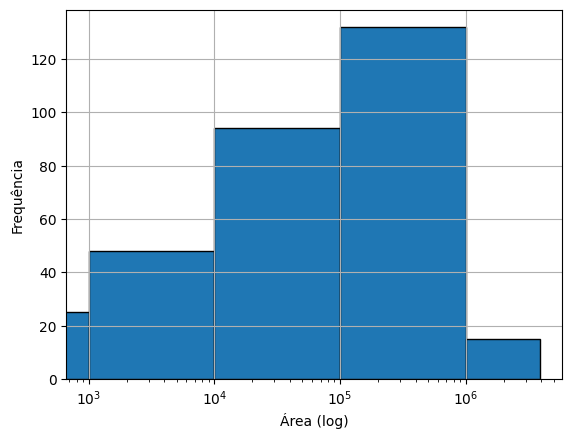

In [5]:
def area(x):
  if x<=1000: return "<1000"
  elif x<10000: return "1000-9999"
  elif x<100000: return "10000-99999"
  elif x<1000000: return "100000-999999"
  elif x>=100000: return ">=1000000"

df_baseED['area'] = df_baseED['área_ha_uc'].apply(area)
print(df_baseED.area.value_counts().sort_index())

bins = [0, 1000, 10000, 100000, 1000000, 3870000]  # Intervalos personalizados

# Plotando o histograma
df_baseED['área_ha_uc'].hist(bins=bins, edgecolor='black')
plt.xscale('log')
plt.xlabel('Área (log)')
plt.ylabel('Frequência')
#plt.title('Histograma de Áreas')
plt.show()

#df_baseED['area'] = df_baseED['área_ha_uc'].apply(area);
# df_baseED.area.hist()


#### Variável: Área desmatada anual
O dataset contém 16 variáveis de área desmatada anual, uma para cada anos do período de 2008 a 2023. Para exemplificar a distribuição dos valores nessa variável, foi utilizado o ano de 2016.
<br>No ano de 2016, não houve dematamento em cerca de metade das UCs (140), enquanto em 7 delas o desmatamento foi maior que 1000ha.

In [6]:
df_baseED[2016].describe()

count     314.000000
mean      141.152834
std       707.492402
min         0.000000
25%         0.000000
50%         1.000000
75%        33.072500
max      7305.890000
Name: 2016, dtype: float64

area2016
0          150
0,1-9       44
10-99       72
100-999     41
>=1000       7
Name: count, dtype: int64


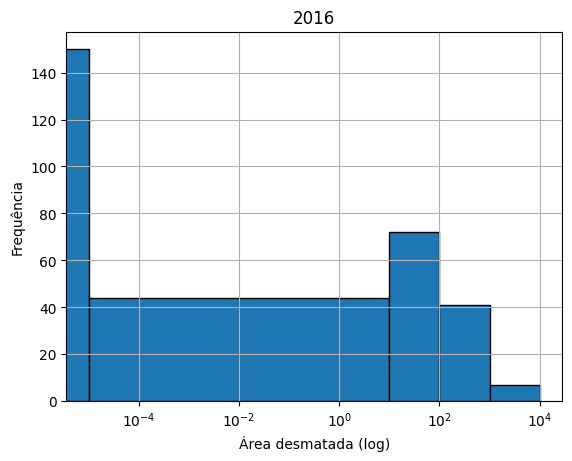

In [7]:
def areadesmat(x):
  if x==0: return "0"
  elif x<10: return "0,1-9"
  elif x<100: return "10-99"
  elif x<1000: return "100-999"
  elif x>=1000: return ">=1000"

df_baseED['area2016'] = df_baseED[2016].apply(areadesmat);
print(df_baseED.area2016.value_counts().sort_index())

bins = [0, 0.00001, 10, 100, 1000, 10000] 

# Plotando o histograma
df_baseED[2016].hist(bins=bins, edgecolor='black')
plt.xscale('log')
plt.xlabel('Área desmatada (log)')
plt.ylabel('Frequência')
plt.title('2016')
plt.show()


#### Variável: UF
As UCs federais estão presentes em todos os estados e no DF, algumas delas abrangem mais de um Estado. O Pará (51) e o Amazonas (49) são os estados com mais UCs, enquanto Rio Grande do Norte e Mato Grosso do Sul tem menos (4). 15 estados tem 10 ou menos UCs  

<Axes: xlabel='UF'>

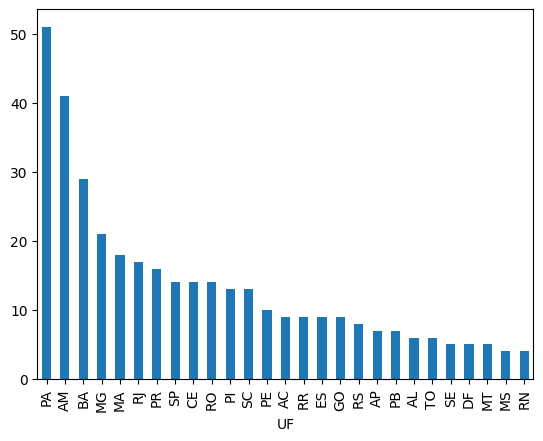

In [8]:
# (20) UF: variável qualitativa nominal
df_baseED_UF = df_baseED['UF'].str.split(', ')
df_baseED_UF = df_baseED_UF.explode('UF')
#print(df_baseED_UF.value_counts().sort_values())
#df_baseED_UF.describe()
df_baseED_UF.value_counts().plot(kind='bar')

#### Variável: Plano de Manejo
168 UCs tem Planos de Manejo publicados, ao passo que 38 não tem. Não há informação para 108 delas 

In [9]:
# (22) Plano de Manejo: variável qualitativa nominal
df_baseED['Plano de Manejo'].value_counts() 

Plano de Manejo
Sim               168
Sem Informação    108
Não                38
Name: count, dtype: int64

#### Variável: Categoria de Manejo
A maioria das UCs pertence às categorias de Parque Nacional (75), Reserva Extrativista (67) e Floresta Nacional (64), enquanto as ARIEs, RVS, RDS e MONA representam menos de 10 UCs cada.

Categoria (Sigla)
PARNA    75
RESEX    67
FLONA    64
APA      40
REBIO    28
ESEC     22
ARIE      7
RVS       7
RDS       2
MONA      2
Name: count, dtype: int64


<Axes: xlabel='Categoria (Sigla)'>

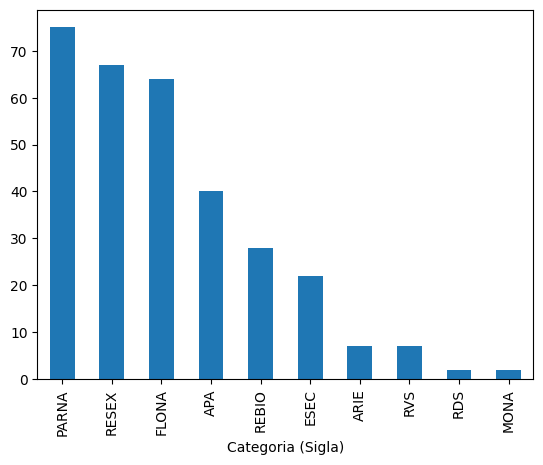

In [10]:
# (23) Categoria (Sigla): variável qualitativa nominal
print(df_baseED['Categoria (Sigla)'].value_counts().sort_values(ascending=0)) 
df_baseED['Categoria (Sigla)'].value_counts().plot(kind='bar')

#### Variável: Grupo
180 UCs são de Uso Sustentável ao passo que 134 são de Proteção Integral

Grupo (Sigla)
PI    134
US    180
Name: count, dtype: int64


<Axes: xlabel='Grupo (Sigla)'>

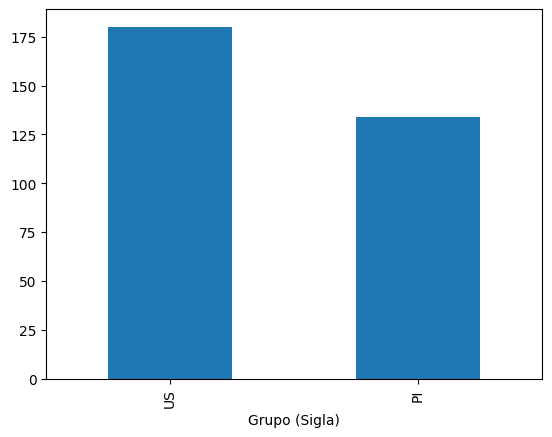

In [11]:
# (24) Grupo (Sigla): variável qualitativa nominal
print(df_baseED['Grupo (Sigla)'].value_counts().sort_index())
df_baseED['Grupo (Sigla)'].value_counts().plot(kind='bar')

#### Variável: Bioma
Esta variável representa o bioma majoritário em dada UC, que muitas vezes não é o único.
<br> 130 UCs tem o bioma Amazônia como predominante e apenas 3 tem o Pampa

Bioma
Pampa               3
Marinho            15
Caatinga           31
Cerrado            45
Mata Atlântica     90
Amazônia          130
Name: count, dtype: int64


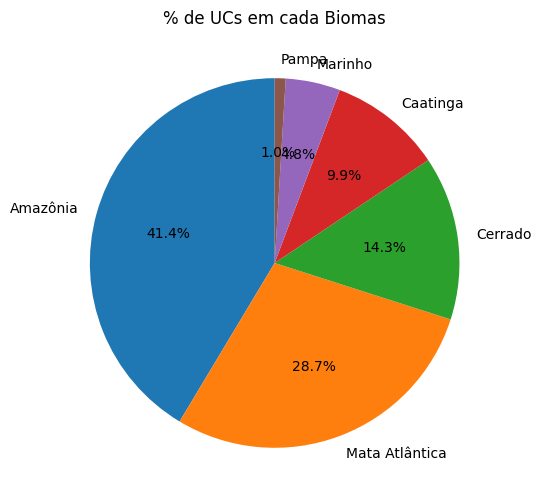

In [12]:
# (25) Bioma: variável qualitativa nominal
print(df_baseED['Bioma'].value_counts().sort_values())
#df_baseED['Bioma'].hist()

contagem_bioma = df_baseED['Bioma'].value_counts()

# Criando o gráfico de pizza
contagem_bioma.plot(kind='pie', autopct='%.1f%%', startangle=90, figsize=(6, 6))
plt.title('% de UCs em cada Biomas')
plt.ylabel('')  # Remove o label do eixo y
plt.show()



#### Variável: Ano de criação
As primeira UC foi criada em 1.934 e a última em 2.023. Considerando o período posterior a 1960, a década com maior número de UCs criadas foi a de 2000 a 2009 (115) e a com menor número de criações foi a de 1970 a 1979.

In [13]:
df_baseED['Ano de Criação'].describe()

count     314.000000
mean     1995.242038
std        15.121827
min      1934.000000
25%      1986.500000
50%      1999.000000
75%      2005.750000
max      2023.000000
Name: Ano de Criação, dtype: float64

In [14]:
def criacao(x):
  try:
      x = int(x)
  except:
      return pd.NA

  if x<1960: return "<1960"
  elif x<1970: return "1960-1969"
  elif x<1980: return "1970-1979"
  elif x<1990: return "1980-1989"
  elif x<2000: return "1990-1999"
  elif x<2010: return "2000-2009"
  elif x<2020: return "2010-2019"
  elif x>=2020: return ">2020"

  return pd.NA

df_baseED['faixas'] = df_baseED['Ano de Criação'].apply(criacao);
print(df_baseED.faixas.value_counts().sort_index())



faixas
1960-1969     16
1970-1979     11
1980-1989     69
1990-1999     57
2000-2009    115
2010-2019     38
<1960          6
>2020          2
Name: count, dtype: int64


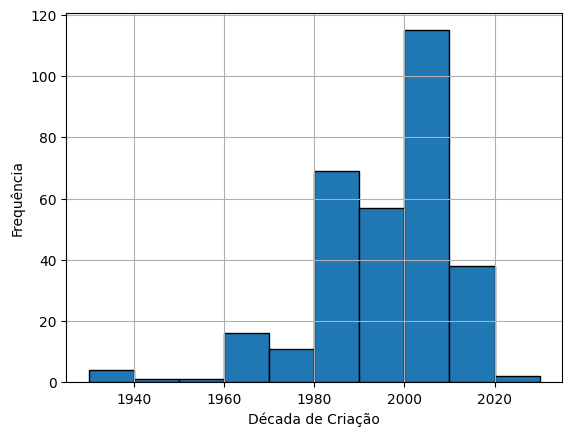

In [15]:
bins = [1930,1940,1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020, 2030] 

# Plotando o histograma
df_baseED['Ano de Criação'].hist(bins=bins, edgecolor='black')
plt.xlabel('Década de Criação')
plt.ylabel('Frequência')
plt.show()


## Medidas de tendência central

### Variável: Área desmatada anual (2016)

In [20]:
print(df_baseED[2016].mean())
print(df_baseED[2016].median())
print(df_baseED[2016].mode())
df_baseED[2016].describe()

141.15283439490446
1.0
0    0.0
Name: 2016, dtype: float64


count     314.000000
mean      141.152834
std       707.492402
min         0.000000
25%         0.000000
50%         1.000000
75%        33.072500
max      7305.890000
Name: 2016, dtype: float64

#### 1.1. Anote no caderno de análise se essas medidas são coincidentes e qual a interpretação associada (tanto para o caso aﬁrmativo, quanto negativo); 

#### 1.2. Identiﬁque também as médias geométrica e harmônica, discorrendo a respeito de qual delas apresenta uma melhor informação acerca da amostra.

In [21]:
print(stats.gmean(df_baseED[2016]))}
print(stats.hmean(df_baseED[2016]))


0.0
0.0


### Exercício 2. Exiba um histograma da variável escolhida, acrescentando:
2.1. Uma linha vertical azul para indicar a moda;
<br>2.2. Uma linha vertical verde para marcar a média; 
<br>2.3. E uma linha vertical cinza para indicar a mediana.

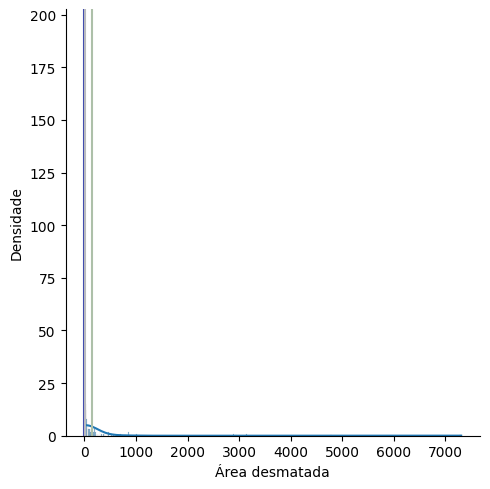

In [29]:
ax = sns.displot(df_baseED, x=2016, kde=True)
ax.set(xlabel='Área desmatada', ylabel='Densidade')
plt.axvline(x=df_baseED[2016].mode().item(), color='#3d49afff')
plt.axvline(x=df_baseED[2016].mean(), color='#adc0a9ff')
plt.axvline(x=df_baseED[2016].median(), color='#b9babfff')

### Exercício 3. Escolha uma variável quantitativa em seu dataset e exiba um boxplot. 

#### Identiﬁque a existência, ou não, de outliers
Calcule os valores mínimo e máximo do boxplot e identiﬁque valores abaixo ou acima desses limites; 
<br> Anote suas conclusões;
<br> Compare o primeiro e terceiro quartil de sua amostra, discorra em seu caderno sobre os achados

## Aula 4

### Exercício 1. Selecione uma variável contínua de interesse e 
Calcule todas as medidas de dispersão apresentadas (variância e desvios amostrais, bem como amplitude, intervalo interquartílico, coeﬁciente de dispersão quartílica e coeﬁciente de variação). 

#### Anote em seu caderno a interpretação das medidas obtidas:
1.1. Sua amostra é concentrada ou dispersa?
<br>1.2. A amplitude interna (IIQ) é proporcional à amplitude total da amostra?
<br>1.3. Quais a implicações dessas informações em relação ao contexto/signiﬁcado concreto dessa variável?

### Exercício 2. Exiba um gráﬁco de dispersão (KDE) da variável estudada
2.1. Sinalize os componentes do IIQ (i.e. Q1 e Q3) com linhas verticais na cor cinza;
<br>2.2. Sinalize, com linhas verticais azuis, a média amostral e o primeiro desvio padrão à esquerda e à direita

### Exercício 3. Exiba um gráﬁco KDE, marcando, quando existir, os outliers;

### Exercício 4. Agora, calcule as medidas de assimetria e curtose da variável analisada;
a) Anote em seu caderno as respectivas interpretações das medidas encontradas;
<br> b) Discorra sobre a existência, ou não, de outliers e sobre uma forma de eliminá-los com base nas medidas de dispersão e forma disponíveis;

## Aula 5

###  Exercício 1. Exiba um gráﬁco de dispersão, do tipo KDE, da sua variável contínua, particionado por alguma variável qualitativa.

### Exercício 2. Exiba o gráﬁco de dispersão do tipo scatter plot de duas variáveis, preferencialmente contínuas, da sua amostra;

### Exercício 3. Exiba gráﬁcos do tipo violin e estude a diferença de dispersão entre subclasses da sua amostra.

### Exercício 4. Selecione duas variáveis categóricas e calcule as medidas de associação. 

### Exercício 5. Selecione duas variáveis contínuas e calcule as medidas de covariância e correlação;

## Aula 6

### Exercício 1. Selecione duas variáveis contínuas no seu dataset e 
calcule os parâmetros de uma regressão simples utilizando o os métodos descritos nesta aula (OLS, MLE, Huber, Quantílico).

### Exercício 2. Selecione três variáveis contínuas, de preferência mantendo a mesma variável dependente do exercício anterior, e 
calcule os parâmetros de regressão utilizando os métodos de regressão multivariada apresentados;

###  Exercício 3. Selecione uma série temporal, decomponha e analise os componentes (tendência, sazonalidade e ruído).

### Exercício 4. Exiba a média móvel da sua série;